# ML + QAOA Drug Candidate Selection Using IBM Qiskit

This notebook demonstrates a simple pharma-inspired workflow:

1. Use **classical machine learning** to predict molecular solubility.
2. Use **classical optimization baselines** to solve the candidate-selection problem.
3. Use **QAOA** to select the best small portfolio of molecules from the ML-scored candidates.

That distinction matters: QAOA does **not** predict solubility. QAOA solves the selection optimization problem after we already have candidate scores.

Dataset: Delaney ESOL from MoleculeNet/DeepChem.

CSV source: https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv

Documentation: https://deepchem.readthedocs.io/en/latest/api_reference/moleculenet.html

Architecture reference: see `../docs/architecture.md` for the QAOA/VQE data flow and algorithm roles.


## Workflow

The project is split into two problems:

| Step | Question | Method |
|---|---|---|
| Prediction | What is a molecule's likely measured log solubility? | Classical ML regression |
| Optimization baseline | What is the exact best three-molecule selection? | Classical brute force enumeration |
| Optimization heuristic | Can a scalable classical heuristic find the same selection? | Simulated annealing |
| Quantum optimization | Can QAOA recover a high-scoring feasible selection? | QAOA |

We compare ML models for prediction quality, then compare simulated annealing and QAOA against the exact classical optimizer for selection quality.


In [1]:
from pathlib import Path
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
CANDIDATE_POOL_SIZE = 8
SELECT_COUNT = 3
SAMPLER_SHOTS = 4096
QAOA_REPS = 3
QAOA_MAXITER = 200
QAOA_REPS_GRID = [1, 2, 3]

np.random.seed(RANDOM_SEED)


## 1. Load the ESOL Dataset

ESOL contains real molecules, SMILES strings, measured aqueous solubility, and simple molecular descriptors. The local CSV is used if present; otherwise the notebook falls back to the public URL.


In [2]:
DATA_URL = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
local_paths = [Path("data/delaney-processed.csv"), Path("../data/delaney-processed.csv")]
data_path = next((path for path in local_paths if path.exists()), None)

df = pd.read_csv(data_path if data_path else DATA_URL)

print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head()

Rows: 1128
Columns: ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


## 2. Train Classical ML Baselines

We train a few simple regression models to predict measured log solubility. These are the prediction baselines. QAOA is not involved in this step.


In [3]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

feature_columns = [
    "ESOL predicted log solubility in mols per litre",
    "Minimum Degree",
    "Molecular Weight",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Polar Surface Area",
]
target_column = "measured log solubility in mols per litre"

X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED
)

models = {
    "Linear Regression": Pipeline(
        [("scaler", StandardScaler()), ("model", LinearRegression())]
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=250, random_state=RANDOM_SEED, min_samples_leaf=2
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_SEED),
}

metrics = []
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = mean_squared_error(y_test, predictions) ** 0.5
    metrics.append(
        {
            "model": name,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": rmse,
            "R2": r2_score(y_test, predictions),
        }
    )
    trained_models[name] = model

metrics_df = pd.DataFrame(metrics).sort_values("RMSE").reset_index(drop=True)
best_model_name = metrics_df.loc[0, "model"]
best_model = trained_models[best_model_name]

print("Best model by test RMSE:", best_model_name)
metrics_df

Best model by test RMSE: Random Forest


,model,MAE,RMSE,R2
0,Random Forest,0.457477,0.630540,0.914881
1,Gradient Boosting,0.475169,0.645639,0.910755
2,Linear Regression,0.634096,0.861980,0.840926


## 3. Inspect Prediction Quality

The plot compares measured solubility against predictions from the best classical ML model.


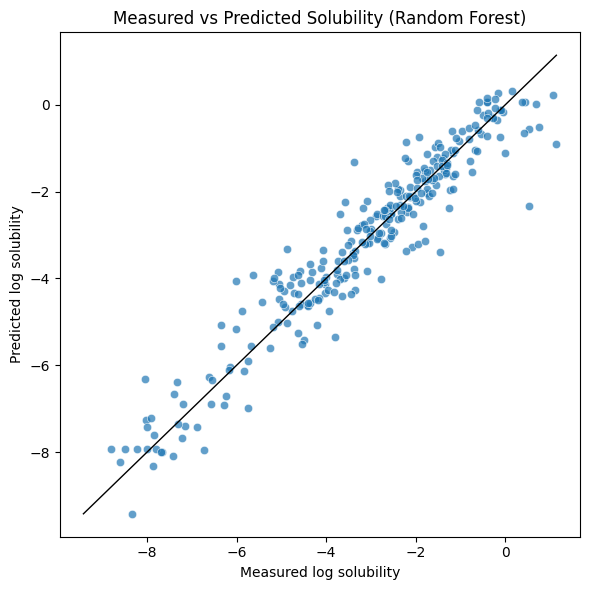

In [4]:
best_predictions = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, best_predictions, alpha=0.7, edgecolor="white", linewidth=0.5)
limits = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
ax.plot(limits, limits, color="black", linewidth=1)
ax.set_title(f"Measured vs Predicted Solubility ({best_model_name})")
ax.set_xlabel("Measured log solubility")
ax.set_ylabel("Predicted log solubility")
plt.tight_layout()
plt.show()

## 4. Build an Out-of-Sample Candidate Pool

Now we move from prediction to optimization. We take candidate molecules from the test set so their ML scores are out-of-sample predictions.


In [5]:
test_frame = df.loc[X_test.index].copy()
test_frame["predicted_log_solubility"] = best_predictions

filtered_test = test_frame[
    test_frame["Molecular Weight"].between(150, 500)
    & (test_frame["Number of H-Bond Donors"] <= 5)
    & (test_frame["Number of Rotatable Bonds"] <= 8)
    & (test_frame["Number of Rings"] >= 1)
].copy()

candidate_pool = filtered_test.sample(CANDIDATE_POOL_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)
candidate_pool["variable"] = [f"x_{i}" for i in candidate_pool.index]

candidate_pool[[
    "variable",
    "Compound ID",
    "smiles",
    "measured log solubility in mols per litre",
    "predicted_log_solubility",
    "Molecular Weight",
    "Polar Surface Area",
    "Number of Rotatable Bonds",
]]


,variable,Compound ID,smiles,measured log solubility in mols per litre,predicted_log_solubility,Molecular Weight,Polar Surface Area,Number of Rotatable Bonds
0,x_0,Triphenylene,c1ccc2c(c1)c3ccccc3c4ccccc24,-6.726,-7.959636,228.294,0.00,0
1,x_1,"1,2,3-Trichlorobenzene",Clc1cccc(Cl)c1Cl,-4.000,-3.975517,181.449,0.00,0
2,x_2,Camphor,CC1(C)C2CCC1(C)C(=O)C2,-1.960,-1.727514,152.237,17.07,0
3,x_3,Reposal,CCC1(C(=O)NC(=O)NC1=O)C2=CCC3CCC2C3,-2.696,-3.184331,262.309,75.27,2
4,x_4,Deoxycorticosterone,CC12CCC3C(CCC4=CC(=O)CCC34C)C2CCC1C(=O)CO,-3.450,-4.368507,330.468,54.37,2
5,x_5,4-methoxypteridine,COc1ncnc2nccnc12,-1.110,-1.044449,162.152,60.79,1
6,x_6,p-Bromoiodobenzene,Brc1ccc(I)cc1,-4.560,-4.582831,282.906,0.00,0
7,x_7,Bibenzyl,C(Cc1ccccc1)c2ccccc2,-4.620,-4.346258,182.266,0.00,3


## 5. Create Selection Scores

The optimizer needs one score per molecule. We combine the ML-predicted solubility with simple developability preferences.

This is intentionally simple and interpretable:

- higher predicted solubility is better
- molecular weight closer to 350 Da is preferred
- polar surface area closer to 75 is preferred
- fewer rotatable bonds are preferred


In [6]:
def minmax(series):
    span = series.max() - series.min()
    if span == 0:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (series - series.min()) / span


candidate_pool["predicted_solubility_score"] = minmax(
    candidate_pool["predicted_log_solubility"]
)
candidate_pool["mw_desirability"] = 1 - minmax(
    (candidate_pool["Molecular Weight"] - 350).abs()
)
candidate_pool["psa_desirability"] = 1 - minmax(
    (candidate_pool["Polar Surface Area"] - 75).abs()
)
candidate_pool["rotatable_desirability"] = 1 - minmax(
    candidate_pool["Number of Rotatable Bonds"]
)

candidate_pool["selection_score"] = (
    5 * candidate_pool["predicted_solubility_score"]
    + 2 * candidate_pool["mw_desirability"]
    + 2 * candidate_pool["psa_desirability"]
    + candidate_pool["rotatable_desirability"]
)

candidate_pool[[
    "variable",
    "Compound ID",
    "predicted_log_solubility",
    "measured log solubility in mols per litre",
    "Molecular Weight",
    "Polar Surface Area",
    "Number of Rotatable Bonds",
    "selection_score",
]].sort_values("selection_score", ascending=False)

,variable,Compound ID,predicted_log_solubility,measured log solubility in mols per litre,Molecular Weight,Polar Surface Area,Number of Rotatable Bonds,selection_score
5,x_5,4-methoxypteridine,-1.044449,-1.110,162.152,60.79,1,7.404850
3,x_3,Reposal,-3.184331,-2.696,262.309,75.27,2,7.021261
4,x_4,Deoxycorticosterone,-4.368507,-3.450,330.468,54.37,2,6.384991
2,x_2,Camphor,-1.727514,-1.960,152.237,17.07,0,5.962957
6,x_6,p-Bromoiodobenzene,-4.582831,-4.560,282.906,0.00,0,4.907875
1,x_1,"1,2,3-Trichlorobenzene",-3.975517,-4.000,181.449,0.00,0,4.208502
7,x_7,Bibenzyl,-4.346258,-4.620,182.266,0.00,3,2.949606
0,x_0,Triphenylene,-7.959636,-6.726,228.294,0.00,0,1.853465


## 6. Classical Optimizer Baseline

This is the right baseline for QAOA. Since we only have eight candidates, brute force can enumerate all possible groups of three and find the exact best selection.


In [7]:
def score_selection(indices, frame):
    return float(frame.loc[list(indices), "selection_score"].sum())


all_solutions = []
for combo in itertools.combinations(candidate_pool.index, SELECT_COUNT):
    selected_names = candidate_pool.loc[list(combo), "Compound ID"].tolist()
    all_solutions.append(
        {
            "selected_indices": combo,
            "selected_candidates": selected_names,
            "score": score_selection(combo, candidate_pool),
        }
    )

classical_selection = (
    pd.DataFrame(all_solutions).sort_values("score", ascending=False).reset_index(drop=True)
)
best_classical = classical_selection.iloc[0]

print("Classical optimizer optimum")
print("Selected:", best_classical["selected_candidates"])
print("Score:", round(best_classical["score"], 4))
classical_selection.head(10)


Classical optimizer optimum
Selected: ['Reposal', 'Deoxycorticosterone', '4-methoxypteridine']
Score: 20.8111


,selected_indices,selected_candidates,score
0,"(3, 4, 5)","[Reposal, Deoxycorticosterone, 4-methoxypterid...",20.811102
1,"(2, 3, 5)","[Camphor, Reposal, 4-methoxypteridine]",20.389069
2,"(2, 4, 5)","[Camphor, Deoxycorticosterone, 4-methoxypterid...",19.752799
3,"(2, 3, 4)","[Camphor, Reposal, Deoxycorticosterone]",19.369210
4,"(3, 5, 6)","[Reposal, 4-methoxypteridine, p-Bromoiodobenzene]",19.333986
5,"(4, 5, 6)","[Deoxycorticosterone, 4-methoxypteridine, p-Br...",18.697716
6,"(1, 3, 5)","[1,2,3-Trichlorobenzene, Reposal, 4-methoxypte...",18.634613
7,"(3, 4, 6)","[Reposal, Deoxycorticosterone, p-Bromoiodobenz...",18.314127
8,"(2, 5, 6)","[Camphor, 4-methoxypteridine, p-Bromoiodobenzene]",18.275682
9,"(1, 4, 5)","[1,2,3-Trichlorobenzene, Deoxycorticosterone, ...",17.998344


## 7. Simulated Annealing Baseline

Brute force is exact, but it only works because this demo has eight candidates. Simulated annealing is a more scalable classical heuristic: it starts with a valid three-molecule portfolio, proposes swaps, and sometimes accepts a worse swap early in the search so it can escape local optima.

Here the neighborhood is simple: remove one selected molecule and add one unselected molecule. That keeps the `select exactly three` constraint satisfied at every step.


In [8]:
def simulated_annealing_selection(
    frame,
    select_count=SELECT_COUNT,
    iterations=2_000,
    initial_temperature=1.0,
    cooling_rate=0.995,
    min_temperature=1e-4,
    seed=RANDOM_SEED,
):
    rng = np.random.default_rng(seed)
    values = frame["selection_score"].to_numpy(dtype=float)
    n_candidates = len(values)

    current_bits = np.zeros(n_candidates, dtype=int)
    current_bits[rng.choice(n_candidates, size=select_count, replace=False)] = 1

    def bitstring_score(bits):
        return float(values[bits == 1].sum())

    current_score = bitstring_score(current_bits)
    best_bits = current_bits.copy()
    best_score = current_score
    temperature = initial_temperature
    trace = []

    for step in range(1, iterations + 1):
        proposal_bits = current_bits.copy()
        selected = np.flatnonzero(proposal_bits == 1)
        unselected = np.flatnonzero(proposal_bits == 0)

        remove_idx = rng.choice(selected)
        add_idx = rng.choice(unselected)
        proposal_bits[remove_idx] = 0
        proposal_bits[add_idx] = 1

        proposal_score = bitstring_score(proposal_bits)
        score_delta = proposal_score - current_score
        accept_worse_probability = (
            1.0
            if score_delta >= 0
            else np.exp(score_delta / max(temperature, min_temperature))
        )

        if rng.random() < accept_worse_probability:
            current_bits = proposal_bits
            current_score = proposal_score

            if current_score > best_score:
                best_bits = current_bits.copy()
                best_score = current_score

        trace.append(
            {
                "step": step,
                "temperature": temperature,
                "current_score": current_score,
                "best_score": best_score,
            }
        )
        temperature = max(temperature * cooling_rate, min_temperature)

    return best_bits, best_score, pd.DataFrame(trace)


annealing_bits, annealing_score, annealing_trace = simulated_annealing_selection(
    candidate_pool
)
annealing_selected = candidate_pool.loc[annealing_bits == 1].copy()

print("Simulated annealing selected candidates:")
display(
    annealing_selected[[
        "Compound ID",
        "smiles",
        "predicted_log_solubility",
        "measured log solubility in mols per litre",
        "selection_score",
    ]]
)
print("Simulated annealing score:", round(annealing_score, 4))
print("Classical optimizer best score:", round(best_classical["score"], 4))
print("Matches classical optimum:", np.isclose(annealing_score, best_classical["score"]))

annealing_trace.tail()


Simulated annealing selected candidates:


,Compound ID,smiles,predicted_log_solubility,measured log solubility in mols per litre,selection_score
3,Reposal,CCC1(C(=O)NC(=O)NC1=O)C2=CCC3CCC2C3,-3.184331,-2.696,7.021261
4,Deoxycorticosterone,CC12CCC3C(CCC4=CC(=O)CCC34C)C2CCC1C(=O)CO,-4.368507,-3.450,6.384991
5,4-methoxypteridine,COc1ncnc2nccnc12,-1.044449,-1.110,7.404850


Simulated annealing score: 20.8111
Classical optimizer best score: 20.8111
Matches classical optimum: True


,step,temperature,current_score,best_score
1995,1996,0.0001,20.811102,20.811102
1996,1997,0.0001,20.811102,20.811102
1997,1998,0.0001,20.811102,20.811102
1998,1999,0.0001,20.811102,20.811102
1999,2000,0.0001,20.811102,20.811102


## 8. Plot Simulated Annealing Trace

The trace shows how the heuristic explores early, then stabilizes as the temperature cools. The `best_score` line should move upward and then plateau.


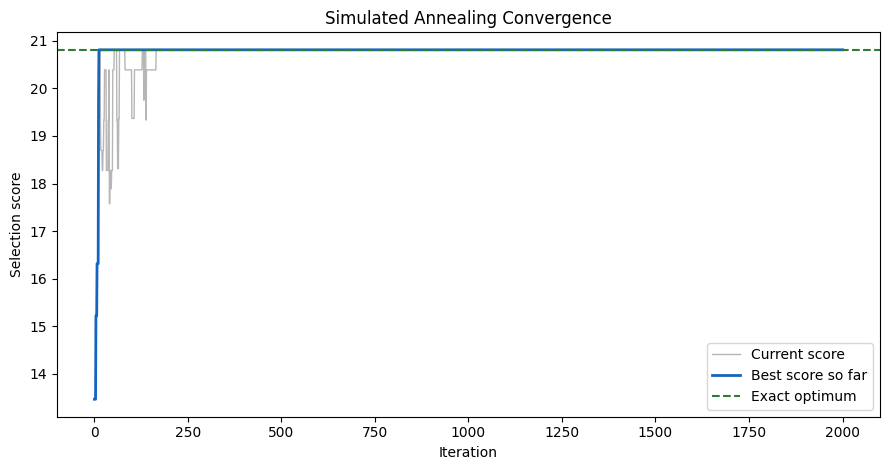

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(
    annealing_trace["step"],
    annealing_trace["current_score"],
    color="#9e9e9e",
    linewidth=1,
    alpha=0.75,
    label="Current score",
)
ax.plot(
    annealing_trace["step"],
    annealing_trace["best_score"],
    color="#1565c0",
    linewidth=2,
    label="Best score so far",
)
ax.axhline(
    float(best_classical["score"]),
    color="#2e7d32",
    linestyle="--",
    linewidth=1.5,
    label="Exact optimum",
)
ax.set_title("Simulated Annealing Convergence")
ax.set_xlabel("Iteration")
ax.set_ylabel("Selection score")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Build the Qiskit Optimization Problem

We express the selection problem with binary variables and the constraint that exactly three molecules must be selected.


In [10]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

problem = QuadraticProgram("ml_scored_esol_candidate_selection")

for variable in candidate_pool["variable"]:
    problem.binary_var(name=variable)

linear_objective = {
    row.variable: float(row.selection_score)
    for row in candidate_pool.itertuples(index=False)
}

problem.maximize(linear=linear_objective)
problem.linear_constraint(
    linear={variable: 1 for variable in candidate_pool["variable"]},
    sense="==",
    rhs=SELECT_COUNT,
    name="select_exactly_three",
)

print(problem.prettyprint())


Problem name: ml_scored_esol_candidate_selection

Maximize
  1.8534654465272593*x_0 + 4.2085020436813405*x_1 + 5.9629574199570765*x_2
  + 7.021260781910933*x_3 + 6.384991302763599*x_4 + 7.4048503645296675*x_5
  + 4.907874585407567*x_6 + 2.9496064769583366*x_7

Subject to
  Linear constraints (1)
    x_0 + x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 == 3  'select_exactly_three'

  Binary variables (8)
    x_0 x_1 x_2 x_3 x_4 x_5 x_6 x_7



In [11]:
qubo_converter = QuadraticProgramToQubo()
qubo = qubo_converter.convert(problem)
print(qubo.prettyprint())

Problem name: ml_scored_esol_candidate_selection

Minimize
  41.69350842173578*x_0^2 + 83.38701684347156*x_0*x_1
  + 83.38701684347156*x_0*x_2 + 83.38701684347156*x_0*x_3
  + 83.38701684347156*x_0*x_4 + 83.38701684347156*x_0*x_5
  + 83.38701684347156*x_0*x_6 + 83.38701684347156*x_0*x_7
  + 41.69350842173578*x_1^2 + 83.38701684347156*x_1*x_2
  + 83.38701684347156*x_1*x_3 + 83.38701684347156*x_1*x_4
  + 83.38701684347156*x_1*x_5 + 83.38701684347156*x_1*x_6
  + 83.38701684347156*x_1*x_7 + 41.69350842173578*x_2^2
  + 83.38701684347156*x_2*x_3 + 83.38701684347156*x_2*x_4
  + 83.38701684347156*x_2*x_5 + 83.38701684347156*x_2*x_6
  + 83.38701684347156*x_2*x_7 + 41.69350842173578*x_3^2
  + 83.38701684347156*x_3*x_4 + 83.38701684347156*x_3*x_5
  + 83.38701684347156*x_3*x_6 + 83.38701684347156*x_3*x_7
  + 41.69350842173578*x_4^2 + 83.38701684347156*x_4*x_5
  + 83.38701684347156*x_4*x_6 + 83.38701684347156*x_4*x_7
  + 41.69350842173578*x_5^2 + 83.38701684347156*x_5*x_6
  + 83.38701684347156*x_5*x

## 10. Solve the Selection Problem with QAOA

QAOA now receives the ML-derived selection problem. It is optimizing a subset choice, not predicting solubility.


In [12]:
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer


def make_sampler(seed=RANDOM_SEED):
    """Create a sampler across common Qiskit versions."""
    try:
        from qiskit.primitives import Sampler

        return Sampler(options={"seed": seed, "shots": SAMPLER_SHOTS})
    except Exception:
        from qiskit.primitives import StatevectorSampler

        return StatevectorSampler(seed=seed)


sampler = make_sampler()
optimizer = COBYLA(maxiter=QAOA_MAXITER)
qaoa = QAOA(sampler=sampler, optimizer=optimizer, reps=QAOA_REPS)

qaoa_optimizer = MinimumEigenOptimizer(qaoa)
qaoa_result = qaoa_optimizer.solve(problem)

print(qaoa_result)


fval=20.38906856639768, x_0=0.0, x_1=0.0, x_2=1.0, x_3=1.0, x_4=0.0, x_5=1.0, x_6=0.0, x_7=0.0, status=SUCCESS


## 11. Compare Optimization Results


In [13]:
selection_bits = np.array(qaoa_result.x).astype(int)
qaoa_selected = candidate_pool.loc[selection_bits == 1].copy()
qaoa_score = float(qaoa_selected["selection_score"].sum())

comparison = pd.DataFrame(
    [
        {
            "method": "Exact brute force",
            "score": float(best_classical["score"]),
            "selected_candidates": best_classical["selected_candidates"],
            "matches_exact": True,
        },
        {
            "method": "Simulated annealing",
            "score": annealing_score,
            "selected_candidates": annealing_selected["Compound ID"].tolist(),
            "matches_exact": np.isclose(annealing_score, best_classical["score"]),
        },
        {
            "method": "QAOA",
            "score": qaoa_score,
            "selected_candidates": qaoa_selected["Compound ID"].tolist(),
            "matches_exact": np.isclose(qaoa_score, best_classical["score"]),
        },
    ]
)
comparison["optimality_gap"] = float(best_classical["score"]) - comparison["score"]
comparison["optimality_gap_pct"] = (
    100 * comparison["optimality_gap"] / float(best_classical["score"])
)

display(comparison)

print("QAOA selected candidates:")
display(
    qaoa_selected[[
        "Compound ID",
        "smiles",
        "predicted_log_solubility",
        "measured log solubility in mols per litre",
        "selection_score",
    ]]
)


,method,score,selected_candidates,matches_exact,optimality_gap,optimality_gap_pct
0,Exact brute force,20.811102,"[Reposal, Deoxycorticosterone, 4-methoxypterid...",True,0.000000,0.000000
1,Simulated annealing,20.811102,"[Reposal, Deoxycorticosterone, 4-methoxypterid...",True,0.000000,0.000000
2,QAOA,20.389069,"[Camphor, Reposal, 4-methoxypteridine]",False,0.422034,2.027927


QAOA selected candidates:


,Compound ID,smiles,predicted_log_solubility,measured log solubility in mols per litre,selection_score
2,Camphor,CC1(C)C2CCC1(C)C(=O)C2,-1.727514,-1.960,5.962957
3,Reposal,CCC1(C(=O)NC(=O)NC1=O)C2=CCC3CCC2C3,-3.184331,-2.696,7.021261
5,4-methoxypteridine,COc1ncnc2nccnc12,-1.044449,-1.110,7.404850


## 12. Plot QAOA Bitstring Probabilities

The optimizer returns one selected solution, but QAOA samples a distribution over bitstrings. This chart shows the most likely measured bitstrings and whether each one satisfies the exact-three selection constraint.


,bitstring,probability,selected_count,feasible,score,selected_candidates
0,11010000,0.070557,3,True,13.083228,"[Triphenylene, 1,2,3-Trichlorobenzene, Reposal]"
1,11010001,0.010118,4,False,NaN,"[Triphenylene, 1,2,3-Trichlorobenzene, Reposal..."
2,11010100,0.009728,4,False,NaN,"[Triphenylene, 1,2,3-Trichlorobenzene, Reposal..."
3,11000000,0.003320,2,False,NaN,"[Triphenylene, 1,2,3-Trichlorobenzene]"
4,11110000,0.002384,4,False,NaN,"[Triphenylene, 1,2,3-Trichlorobenzene, Camphor..."
5,11000100,0.000802,3,True,13.466818,"[Triphenylene, 1,2,3-Trichlorobenzene, 4-metho..."
6,11000001,0.000802,3,True,9.011574,"[Triphenylene, 1,2,3-Trichlorobenzene, Bibenzyl ]"
7,01010000,0.000596,2,False,NaN,"[1,2,3-Trichlorobenzene, Reposal]"
8,11110100,0.000421,5,False,NaN,"[Triphenylene, 1,2,3-Trichlorobenzene, Camphor..."
9,11010011,0.000344,5,False,NaN,"[Triphenylene, 1,2,3-Trichlorobenzene, Reposal..."


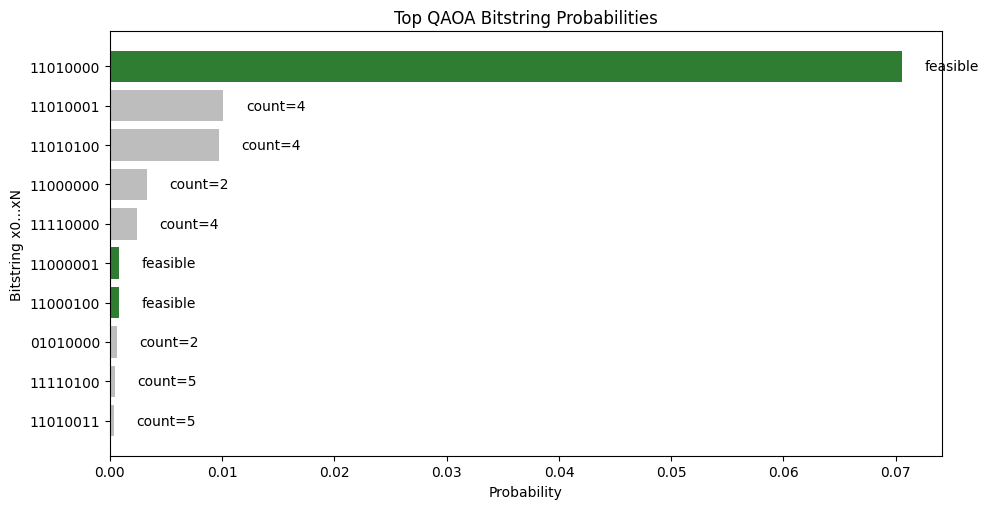

In [14]:
def qaoa_sample_probability_frame(result, frame, top_k=10):
    rows = []
    samples = getattr(result, "samples", []) or []
    for sample in samples:
        bits = np.array(sample.x).astype(int)
        bitstring = "".join(str(int(bit)) for bit in bits)
        selected = frame.loc[bits == 1, "Compound ID"].tolist()
        feasible = int(bits.sum()) == SELECT_COUNT
        rows.append(
            {
                "bitstring": bitstring,
                "probability": float(getattr(sample, "probability", np.nan)),
                "selected_count": int(bits.sum()),
                "feasible": feasible,
                "score": float(frame.loc[bits == 1, "selection_score"].sum()) if feasible else np.nan,
                "selected_candidates": selected,
            }
        )

    if not rows:
        return pd.DataFrame(
            columns=[
                "bitstring",
                "probability",
                "selected_count",
                "feasible",
                "score",
                "selected_candidates",
            ]
        )

    probability_frame = pd.DataFrame(rows)
    probability_frame = (
        probability_frame.groupby("bitstring", as_index=False)
        .agg(
            probability=("probability", "sum"),
            selected_count=("selected_count", "first"),
            feasible=("feasible", "first"),
            score=("score", "first"),
            selected_candidates=("selected_candidates", "first"),
        )
        .sort_values("probability", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )
    return probability_frame


qaoa_probabilities = qaoa_sample_probability_frame(qaoa_result, candidate_pool, top_k=10)
display(qaoa_probabilities)

if qaoa_probabilities.empty:
    print("This Qiskit result object did not expose sample probabilities.")
else:
    plot_probs = qaoa_probabilities.sort_values("probability", ascending=True)
    colors = np.where(plot_probs["feasible"], "#2e7d32", "#bdbdbd")

    fig, ax = plt.subplots(figsize=(10, 5.2))
    ax.barh(plot_probs["bitstring"], plot_probs["probability"], color=colors)
    ax.set_title("Top QAOA Bitstring Probabilities")
    ax.set_xlabel("Probability")
    ax.set_ylabel("Bitstring x0...xN")

    for y_pos, (_, row) in enumerate(plot_probs.iterrows()):
        label = "feasible" if row["feasible"] else f"count={row['selected_count']}"
        ax.text(row["probability"] + 0.002, y_pos, label, va="center")

    plt.tight_layout()
    plt.show()


## 13. QAOA Reps Sensitivity

QAOA depth is controlled by `reps`. This small sweep runs the same optimization with `reps=1,2,3` and compares the resulting optimality gap against the exact brute-force solution.


,reps,feasible,score,optimality_gap,optimality_gap_pct,selected_candidates
0,1,True,20.811102,0.000000,0.000000,"[Reposal, Deoxycorticosterone, 4-methoxypterid..."
1,2,True,20.389069,0.422034,2.027927,"[Camphor, Reposal, 4-methoxypteridine]"
2,3,True,20.389069,0.422034,2.027927,"[Camphor, Reposal, 4-methoxypteridine]"


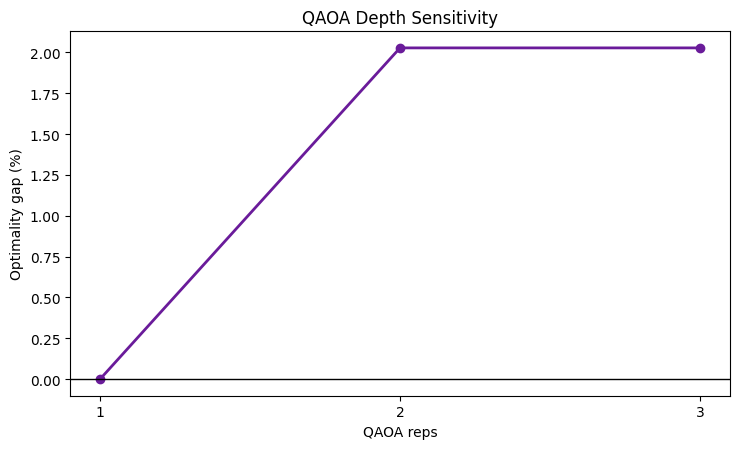

In [15]:
def solve_qaoa_with_reps(reps, seed=RANDOM_SEED):
    if reps == QAOA_REPS:
        result = qaoa_result
    else:
        trial_qaoa = QAOA(
            sampler=make_sampler(seed=seed),
            optimizer=COBYLA(maxiter=QAOA_MAXITER),
            reps=reps,
        )
        result = MinimumEigenOptimizer(trial_qaoa).solve(problem)

    bits = np.array(result.x).astype(int)
    feasible = int(bits.sum()) == SELECT_COUNT
    score = float(candidate_pool.loc[bits == 1, "selection_score"].sum()) if feasible else np.nan
    gap = float(best_classical["score"] - score) if feasible else np.nan
    gap_pct = 100 * gap / float(best_classical["score"]) if feasible else np.nan

    return {
        "reps": reps,
        "feasible": feasible,
        "score": score,
        "optimality_gap": gap,
        "optimality_gap_pct": gap_pct,
        "selected_candidates": candidate_pool.loc[bits == 1, "Compound ID"].tolist(),
    }


qaoa_reps_sensitivity = pd.DataFrame(
    [solve_qaoa_with_reps(reps) for reps in QAOA_REPS_GRID]
)
display(qaoa_reps_sensitivity)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
plot_sensitivity = qaoa_reps_sensitivity.dropna(subset=["optimality_gap_pct"])
ax.plot(
    plot_sensitivity["reps"],
    plot_sensitivity["optimality_gap_pct"],
    marker="o",
    color="#6a1b9a",
    linewidth=2,
)
ax.set_title("QAOA Depth Sensitivity")
ax.set_xlabel("QAOA reps")
ax.set_ylabel("Optimality gap (%)")
ax.set_xticks(QAOA_REPS_GRID)
ax.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()


## 14. Visualize Candidate Selection

Candidates selected by QAOA are highlighted in green. Candidates selected by simulated annealing are marked with an outline.


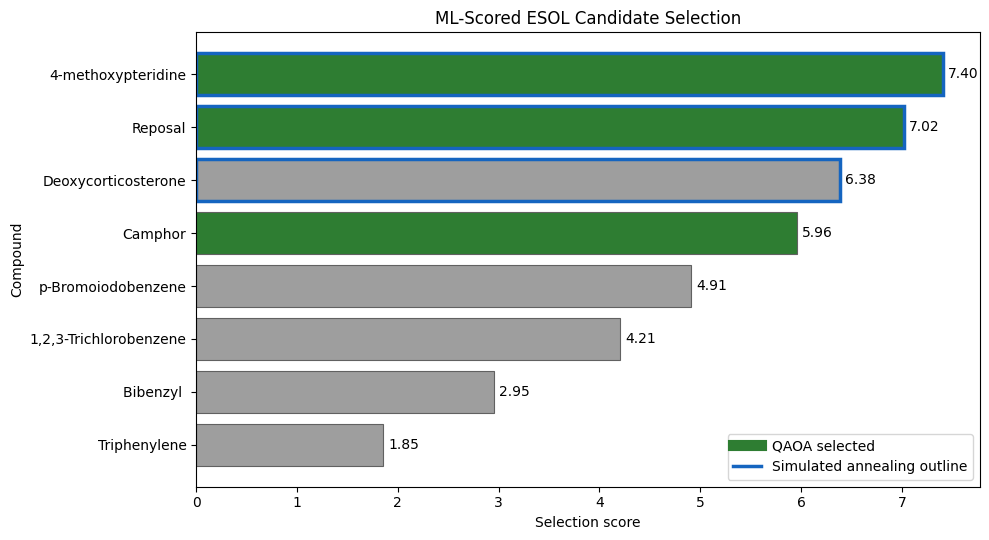

In [16]:
plot_frame = candidate_pool.copy()
plot_frame["selected_by_qaoa"] = selection_bits == 1
plot_frame["selected_by_annealing"] = annealing_bits == 1
plot_frame = plot_frame.sort_values("selection_score", ascending=True)

colors = np.where(plot_frame["selected_by_qaoa"], "#2e7d32", "#9e9e9e")
edge_colors = np.where(plot_frame["selected_by_annealing"], "#1565c0", "#616161")
line_widths = np.where(plot_frame["selected_by_annealing"], 2.5, 0.8)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(
    plot_frame["Compound ID"],
    plot_frame["selection_score"],
    color=colors,
    edgecolor=edge_colors,
    linewidth=line_widths,
)
ax.set_title("ML-Scored ESOL Candidate Selection")
ax.set_xlabel("Selection score")
ax.set_ylabel("Compound")

for bar, value in zip(bars, plot_frame["selection_score"]):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
    )

legend_handles = [
    plt.Line2D([0], [0], color="#2e7d32", lw=8, label="QAOA selected"),
    plt.Line2D([0], [0], color="#1565c0", lw=2.5, label="Simulated annealing outline"),
]
ax.legend(handles=legend_handles, loc="lower right")

plt.tight_layout()
plt.show()


## 15. Conclusion

This notebook uses classical ML for prediction, classical baselines for optimization comparison, and QAOA for quantum optimization.

- Classical ML predicts measured log solubility from molecular descriptors.
- The ML prediction becomes part of a selection score.
- A classical brute-force optimizer gives the exact best selection for this tiny candidate pool.
- Simulated annealing provides a scalable classical heuristic baseline.
- QAOA attempts to recover the same selection as a quantum optimization approach.
- The bitstring probability chart shows which measured solutions QAOA placed probability mass on.
- The reps sensitivity sweep shows how circuit depth changes the optimality gap.
- Because QAOA is approximate and shallow here, it may find a strong feasible selection without always matching the exact classical optimum.

In a larger pharma workflow, the prediction model could use richer molecular fingerprints, docking scores, ADMET predictions, or graph neural network embeddings. The QAOA problem could include constraints such as budget, novelty, toxicity limits, or portfolio diversity.
